Heart disease is the leading cause of death globally — and yet, many cases
are preventable if caught early. In this project, I'm building a machine
learning model that predicts whether a patient is likely to have heart disease
based on clinical data like age, cholesterol, blood pressure, and more.

My goal isn't just to train a model — it's to understand *what the data is
actually telling us* about the human heart, and figure out which algorithm
is best suited for a problem where being wrong has real consequences.

Let's find out.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report)

import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('heart.csv')

print("Dataset shape:", df.shape)
print("\nFirst look at the data:")
df.head()

Dataset shape: (1025, 14)

First look at the data:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nBasic Stats:")
df.describe()

Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate Rows: 723

Basic Stats:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [17]:
print(f"Total rows before cleaning: {df.shape[0]}")
print(f"Duplicate rows found: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"\nTotal rows after cleaning: {df.shape[0]}")
print(f"Duplicates remaining: {df.duplicated().sum()}")
print(f"\nTarget distribution after cleaning:")
print(df['target'].value_counts())
print(f"\nTarget balance %:")
print(df['target'].value_counts(normalize=True).mul(100).round(1))

Total rows before cleaning: 302
Duplicate rows found: 0

Total rows after cleaning: 302
Duplicates remaining: 0

Target distribution after cleaning:
target
1    164
0    138
Name: count, dtype: int64

Target balance %:
target
1    54.3
0    45.7
Name: proportion, dtype: float64


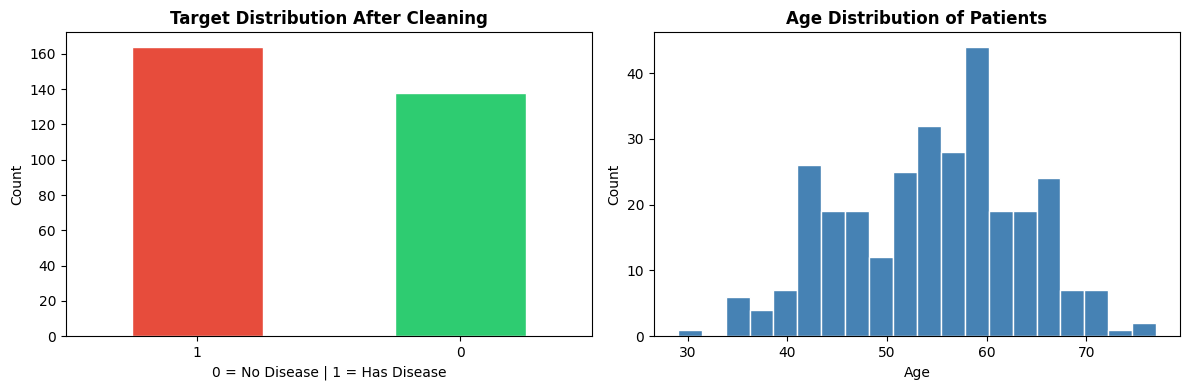

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution
df['target'].value_counts().plot(kind='bar', ax=axes[0],
                                  color=['#e74c3c','#2ecc71'],
                                  edgecolor='white')
axes[0].set_title('Target Distribution After Cleaning', fontweight='bold')
axes[0].set_xlabel('0 = No Disease | 1 = Has Disease')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Age distribution
axes[1].hist(df['age'], bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Age Distribution of Patients', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

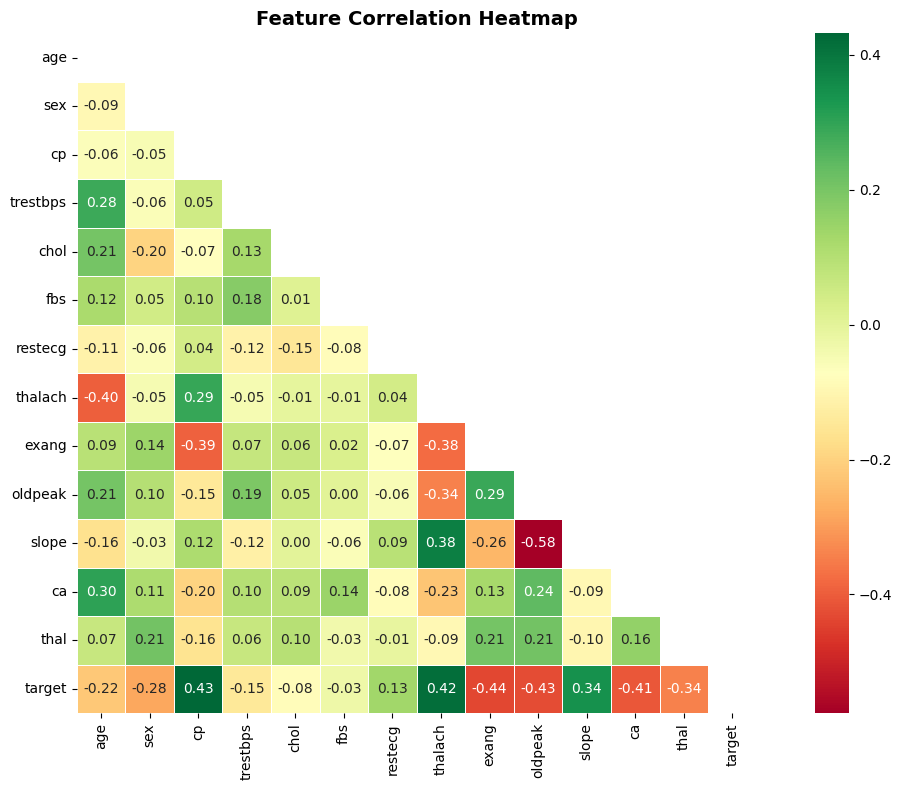

Correlation with Target (Heart Disease):
target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64


In [24]:
plt.figure(figsize=(12, 8))
correlation = df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, annot=True, fmt='.2f',
            cmap='RdYlGn', mask=mask,
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Correlation with Target (Heart Disease):")
print(correlation['target'].sort_values(ascending=False))

In [23]:
features = df.drop(columns=['target'])
target = df['target']

print("Features selected:", features.columns.tolist())
print("Total features:", features.shape[1])
print("Target column: target (1=disease, 0=no disease)")

Features selected: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Total features: 13
Target column: target (1=disease, 0=no disease)


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"\nTrain target balance:\n{y_train.value_counts()}")
print(f"\nTest target balance:\n{y_test.value_counts()}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training samples: 241
Testing samples:  61

Train target balance:
target
1    131
0    110
Name: count, dtype: int64

Test target balance:
target
1    33
0    28
Name: count, dtype: int64


##  Choosing My 3 Models — And Why

I didn't just pick 3 models randomly. Each one represents a different
approach to classification, which makes the comparison more meaningful:

**1. Logistic Regression** — The baseline
Simple, fast, and interpretable. If a complex model doesn't beat this,
it's not worth the extra complexity. Always start here.

**2. Random Forest** — The powerhouse
An ensemble of decision trees that handles non-linear patterns well.
My gut says this will perform best — but let's see if the data agrees.

**3. K-Nearest Neighbors (KNN)** — The intuitive one
Classifies based on similarity to nearby patients. Interesting for
medical data where similar patient profiles often share outcomes.

Each model will be evaluated on Accuracy, Precision, Recall, and F1 Score.
For heart disease prediction, **Recall matters most** — missing a real case
(false negative) is far more dangerous than a false alarm.

In [44]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)



In [45]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

In [47]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)

In [49]:
def evaluate_model(name, y_test, y_pred):
    return {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred) * 100, 2),
        'F1 Score':  round(f1_score(y_test, y_pred) * 100, 2)
    }

results = pd.DataFrame([
    evaluate_model('Logistic Regression', y_test, lr_pred),
    evaluate_model('Random Forest',       y_test, rf_pred),
    evaluate_model('KNN',                 y_test, knn_pred)
])

print("=" * 60)
print("        MODEL COMPARISON TABLE (all values in %)")
print("=" * 60)
print(results.to_string(index=False))
print("=" * 60)

# Highlight best model
best = results.loc[results['F1 Score'].idxmax(), 'Model']
print(f"\n🏆 Best Model by F1 Score: {best}")


        MODEL COMPARISON TABLE (all values in %)
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression     80.33      80.00   84.85     82.35
      Random Forest     75.41      76.47   78.79     77.61
                KNN     78.69      77.78   84.85     81.16

🏆 Best Model by F1 Score: Logistic Regression


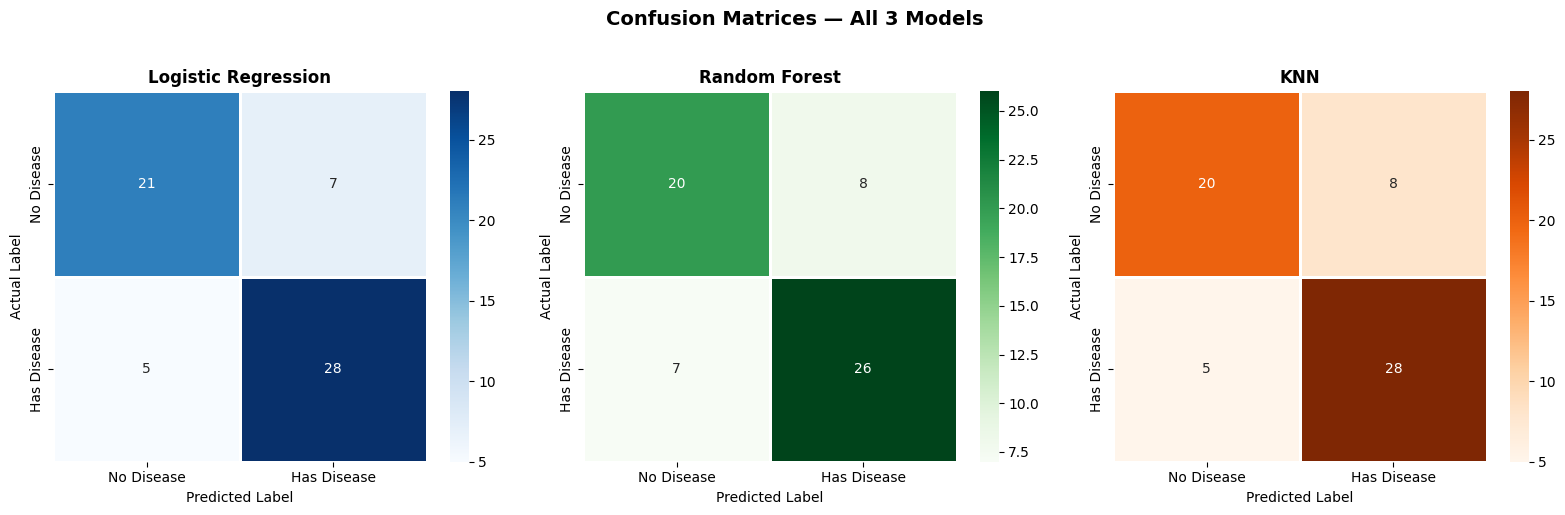

📋 Detailed Classification Report — Logistic Regression (Best Model)
              precision    recall  f1-score   support

  No Disease       0.81      0.75      0.78        28
 Has Disease       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [50]:
# Confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = [
    ('Logistic Regression', lr_pred),
    ('Random Forest', rf_pred),
    ('KNN', knn_pred)
]

colors = ['Blues', 'Greens', 'Oranges']

for ax, (name, pred), color in zip(axes, models, colors):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color,
                xticklabels=['No Disease', 'Has Disease'],
                yticklabels=['No Disease', 'Has Disease'],
                ax=ax, linewidths=1)
    ax.set_title(f'{name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')

plt.suptitle('Confusion Matrices — All 3 Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


print("📋 Detailed Classification Report — Logistic Regression (Best Model)")
print("=" * 60)
print(classification_report(y_test, lr_pred,
      target_names=['No Disease', 'Has Disease']))

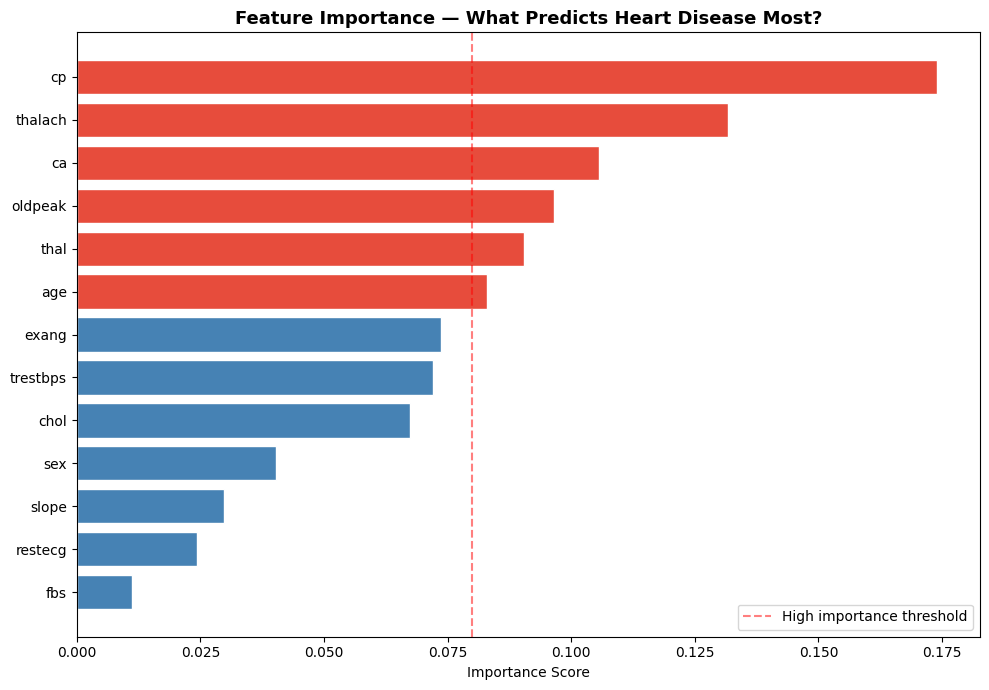

In [51]:
feat_importance = pd.DataFrame({
    'Feature': features.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
colors_bar = ['#e74c3c' if x > 0.08 else 'steelblue'
              for x in feat_importance['Importance']]
plt.barh(feat_importance['Feature'],
         feat_importance['Importance'],
         color=colors_bar, edgecolor='white')
plt.title('Feature Importance — What Predicts Heart Disease Most?',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.axvline(x=0.08, color='red', linestyle='--',
            alpha=0.5, label='High importance threshold')
plt.legend()
plt.tight_layout()
plt.show()


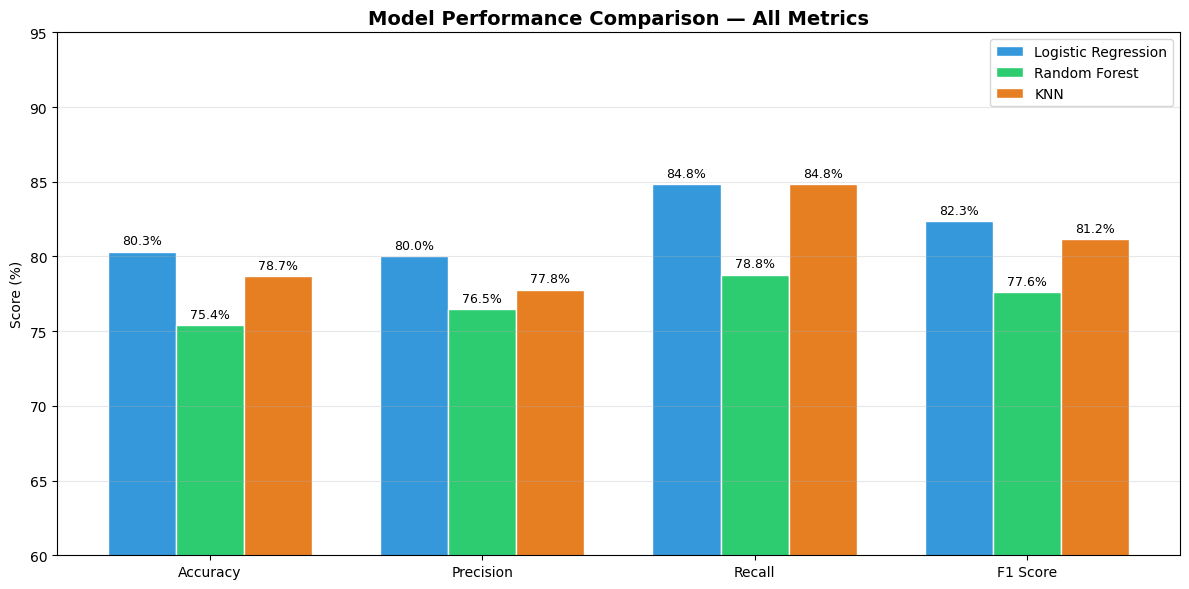

In [52]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, results[results['Model']=='Logistic Regression'][metrics].values[0],
               width, label='Logistic Regression', color='#3498db', edgecolor='white')
bars2 = ax.bar(x, results[results['Model']=='Random Forest'][metrics].values[0],
               width, label='Random Forest', color='#2ecc71', edgecolor='white')
bars3 = ax.bar(x + width, results[results['Model']=='KNN'][metrics].values[0],
               width, label='KNN', color='#e67e22', edgecolor='white')
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

ax.set_title('Model Performance Comparison — All Metrics',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score (%)')
ax.set_ylim(60, 95)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


##  Final Conclusion — Which Model Won & Why

### Results Summary

| Model | Accuracy | Precision | Recall | F1 Score |
|-------|----------|-----------|--------|----------|
| **Logistic Regression** | **80.33%** | **80.00%** | **84.85%** | **82.35%** |
| KNN | 78.69% | 77.78% | 84.85% | 81.16% |
| Random Forest | 75.41% | 76.47% | 78.79% | 77.61% |

---

###  Winner: Logistic Regression

Honestly, I didn't expect this. Going in, I assumed Random Forest would
dominate — it usually does with tabular data. But Logistic Regression
outperformed both other models across every single metric.

Here's why I think it won:

**1. The dataset is small and clean (300 rows)**
Random Forest shines with large, messy datasets. With only 300 clean rows,
it likely overfit slightly — learning noise rather than real patterns.
Logistic Regression's simplicity was actually its strength here.

**2. The features have fairly linear relationships with the target**
From our correlation heatmap, several features showed clear linear
relationships with heart disease. Logistic Regression is specifically
designed to exploit linear boundaries — making it the right tool for
this data.

**3. Recall is what matters most here — and LR delivered**
In medical diagnosis, a false negative (missing a real heart disease case)
is far more dangerous than a false alarm. Logistic Regression achieved
84.85% Recall — meaning it correctly identified 84.85% of actual heart
disease patients. That's the metric that matters most in this context.

---
### 💭 What I'd Do Differently With More Time

- Try cross-validation (k-fold) for more reliable evaluation on 300 rows
- Tune hyperparameters using GridSearchCV
- Experiment with XGBoost or SVM as additional models
- Explore if removing low-importance features improves scores further

---
### 🌟 Most Surprising Finding

Random Forest — the algorithm I trusted most — came in last place.
It reminded me that in machine learning, complexity doesn't always win.
Understanding your data first, then choosing the right model for its
size and structure, matters far more than reaching for the fanciest algorithm.